In [1]:
# ============================================================
# Space-time relative L2 for adam_jax_moose_resample.py
# Loads checkpoint_latest.pkl, NOT snapshot_t_1.csv
# ============================================================

import os
os.environ["JAX_ENABLE_X64"] = "1"

import pickle
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# ----------------------------
# paths
# ----------------------------
npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

ckpt_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/adam_jax_moose_output/checkpoint_latest.pkl"

# ----------------------------
# dtype
# ----------------------------
USE_X64 = True
DTYPE = jnp.float64 if USE_X64 else jnp.float32

# ----------------------------
# load reference MOOSE data
# ----------------------------
data = np.load(npz_path, allow_pickle=True)

x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"], dtype=np.float64)
time_arr = np.array(data["t"], dtype=np.float64) if "t" in data else np.array(data["time"], dtype=np.float64)

T_ref = np.array(data["T"], dtype=np.float64)
phi_ref = np.array(data["phi"], dtype=np.float64)

nt, nx, ny = T_ref.shape

print("Reference shapes:")
print("  x:", x.shape)
print("  y:", y.shape)
print("  t:", time_arr.shape)
print("  T_ref:", T_ref.shape)
print("  phi_ref:", phi_ref.shape)

# ----------------------------
# load trained JAX Adam checkpoint
# ----------------------------
with open(ckpt_path, "rb") as f:
    ckpt = pickle.load(f)

params = ckpt["params"]
cfg = ckpt["config"]

print("Loaded checkpoint step:", ckpt["step"])
print("Network width/layers:", cfg["width"], cfg["layers"])
print("phi_scale:", cfg["phi_scale"], "T_scale:", cfg["T_scale"])

# ----------------------------
# forward function matching training code
# ----------------------------
def activate(z, activation):
    if activation == "tanh":
        return jnp.tanh(z)
    elif activation == "silu":
        return z * jax.nn.sigmoid(z)
    else:
        raise ValueError("activation must be tanh or silu")

def normalize_xyt(xyt):
    # Training code used full domain [0,1]^3 -> [-1,1]^3
    return 2.0 * xyt - 1.0

def mlp_apply(mlp_params, x, activation):
    h = x
    for W, b in mlp_params[:-1]:
        h = activate(jnp.dot(h, W) + b, activation)
    W, b = mlp_params[-1]
    return jnp.dot(h, W) + b

def forward_all(params, xyt, cfg):
    z = normalize_xyt(xyt)

    phi = cfg["phi_scale"] * mlp_apply(params["phi"], z, cfg["activation"])
    Ts  = cfg["T_scale"]   * mlp_apply(params["ts"],  z, cfg["activation"])
    Tf  = cfg["T_scale"]   * mlp_apply(params["tf"],  z, cfg["activation"])

    return jnp.concatenate([phi, Ts, Tf], axis=-1)

@jax.jit
def forward_batch(xyt):
    return forward_all(params, xyt, cfg)

# ----------------------------
# predict over whole space-time grid
# ----------------------------
XX, YY = np.meshgrid(x, y, indexing="ij")

phi_pred_all = np.zeros((nt, nx, ny), dtype=np.float64)
Ts_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)
Tf_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)

chunk = 65536

for k, tk in enumerate(time_arr):
    TT = np.full_like(XX, float(tk), dtype=np.float64)
    X_eval = np.stack(
        [XX.reshape(-1), YY.reshape(-1), TT.reshape(-1)],
        axis=1
    )

    pred_list = []
    for s in range(0, X_eval.shape[0], chunk):
        X_chunk = jnp.asarray(X_eval[s:s + chunk], dtype=DTYPE)
        pred_chunk = np.asarray(forward_batch(X_chunk))
        pred_list.append(pred_chunk)

    pred = np.concatenate(pred_list, axis=0)

    phi_pred_all[k] = pred[:, 0].reshape(nx, ny)
    Ts_pred_all[k]  = pred[:, 1].reshape(nx, ny)
    Tf_pred_all[k]  = pred[:, 2].reshape(nx, ny)

    if k % 5 == 0 or k == nt - 1:
        print(f"predicted time index {k+1}/{nt}, t={tk:.6f}")

# ----------------------------
# masks
# ----------------------------
Ls = 0.4

fuel_mask = x < Ls - 1e-12
cool_mask = x > Ls + 1e-12

print("fuel nx:", fuel_mask.sum())
print("coolant nx:", cool_mask.sum())

# ----------------------------
# space-time relative L2
# ----------------------------
def rel_l2_spacetime(pred_arr, true_arr):
    pred_arr = np.asarray(pred_arr, dtype=np.float64)
    true_arr = np.asarray(true_arr, dtype=np.float64)
    return np.sqrt(
        np.mean((pred_arr - true_arr) ** 2)
        /
        (np.mean(true_arr ** 2) + 1e-30)
    )

phi_rel_st = rel_l2_spacetime(
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :]
)

Ts_rel_st = rel_l2_spacetime(
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :]
)

Tf_rel_st = rel_l2_spacetime(
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :]
)

print("\nSPACE-TIME RELATIVE L2")
print(f"phi (fuel): {phi_rel_st:.6e}")
print(f"Ts  (fuel): {Ts_rel_st:.6e}")
print(f"Tf  (cool): {Tf_rel_st:.6e}")

Reference shapes:
  x: (513,)
  y: (513,)
  t: (1001,)
  T_ref: (1001, 513, 513)
  phi_ref: (1001, 513, 513)
Loaded checkpoint step: 10000
Network width/layers: 64 4
phi_scale: 1.5 T_scale: 3.0
predicted time index 1/1001, t=0.000000
predicted time index 6/1001, t=0.005000
predicted time index 11/1001, t=0.010000
predicted time index 16/1001, t=0.015000
predicted time index 21/1001, t=0.020000
predicted time index 26/1001, t=0.025000
predicted time index 31/1001, t=0.030000
predicted time index 36/1001, t=0.035000
predicted time index 41/1001, t=0.040000
predicted time index 46/1001, t=0.045000
predicted time index 51/1001, t=0.050000
predicted time index 56/1001, t=0.055000
predicted time index 61/1001, t=0.060000
predicted time index 66/1001, t=0.065000
predicted time index 71/1001, t=0.070000
predicted time index 76/1001, t=0.075000
predicted time index 81/1001, t=0.080000
predicted time index 86/1001, t=0.085000
predicted time index 91/1001, t=0.090000
predicted time index 96/1001,

SyntaxError: invalid syntax (3384228244.py, line 1)

: 

In [0]:
SPACE-TIME RELATIVE L2
phi (fuel): 2.122042e-01
Ts  (fuel): 2.844188e-01
Tf  (cool): 5.081282e-01

In [7]:
# ============================================================
# Space-time relative L2 for ALM coupled PINN
#
# Loads:
#   theta_alm_coupled_fixed_no_noise_best.npy
# or:
#   theta_alm_coupled_fixed_no_noise_final.npy
#
# NOT Adam checkpoint_latest.pkl
# ============================================================

import os
os.environ["JAX_ENABLE_X64"] = "1"

from pathlib import Path
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# ----------------------------
# paths
# ----------------------------
npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

theta_candidates = [
    "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_lbfgsb_fixed_no_noise_best.npy",
 
]

theta_path = None
for p in theta_candidates:
    if Path(p).exists():
        theta_path = p
        break

if theta_path is None:
    raise FileNotFoundError(
        "Could not find ALM theta file. Checked:\n"
        + "\n".join(theta_candidates)
    )

print("Using theta file:", theta_path)

# ----------------------------
# dtype
# ----------------------------
USE_X64 = True
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = DTYPE(1e-12)

# ----------------------------
# geometry / normalization
# ----------------------------
Ls = DTYPE(0.4)
Lf = DTYPE(0.6)
Ly = DTYPE(1.0)
T_end = DTYPE(1.0)

x_min = DTYPE(0.0)
x_max = DTYPE(Ls + Lf)
y_min = DTYPE(0.0)
y_max = DTYPE(Ly)
t_min = DTYPE(0.0)
t_max = DTYPE(T_end)

# ----------------------------
# load reference MOOSE data
# ----------------------------
data = np.load(npz_path, allow_pickle=True)

x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"], dtype=np.float64)
time_arr = np.array(data["t"], dtype=np.float64) if "t" in data else np.array(data["time"], dtype=np.float64)

T_ref = np.array(data["T"], dtype=np.float64)
phi_ref = np.array(data["phi"], dtype=np.float64)

nt, nx, ny = T_ref.shape

print("Reference shapes:")
print("  x:", x.shape)
print("  y:", y.shape)
print("  t:", time_arr.shape)
print("  T_ref:", T_ref.shape)
print("  phi_ref:", phi_ref.shape)

# ----------------------------
# load ALM theta
# ----------------------------
theta_np = np.load(theta_path)
theta = jnp.asarray(theta_np, dtype=DTYPE)

print("theta size:", theta_np.size)

# ----------------------------
# infer architecture if possible
# For one MLP:
#   layer_sizes = [3] + [hidden_dim]*num_hidden + [3]
# ----------------------------
def param_count(hidden_dim, num_hidden):
    layer_sizes = [3] + [hidden_dim] * num_hidden + [3]
    total = 0
    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += m * n + n
    return total

def infer_arch(theta_size):
    matches = []
    for H in range(5, 101):
        for L in range(1, 8):
            if param_count(H, L) == theta_size:
                matches.append((H, L))
    return matches

matches = infer_arch(theta_np.size)

if len(matches) == 0:
    raise ValueError(
        f"Could not infer architecture from theta size {theta_np.size}. "
        "Set hidden_dim and num_hidden manually."
    )

# Prefer the SQP/ALM default if possible
if (35, 3) in matches:
    hidden_dim, num_hidden = 35, 3
elif (30, 3) in matches:
    hidden_dim, num_hidden = 30, 3
else:
    hidden_dim, num_hidden = matches[0]

print("Inferred architecture:")
print("  hidden_dim =", hidden_dim)
print("  num_hidden =", num_hidden)

layer_sizes = [3] + [hidden_dim] * num_hidden + [3]
print("  layer_sizes =", layer_sizes)
print("  expected params =", param_count(hidden_dim, num_hidden))

# ----------------------------
# network helpers
# ----------------------------
def normalize_xyt(X):
    xx = X[:, 0:1]
    yy = X[:, 1:2]
    tt = X[:, 2:3]

    x_n = DTYPE(2.0) * (xx - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    y_n = DTYPE(2.0) * (yy - y_min) / (y_max - y_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (tt - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)

    return jnp.concatenate([x_n, y_n, t_n], axis=1)

def unflatten_params(theta, layer_sizes):
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape((m, n))
        idx += w_size

        b = theta[idx:idx + b_size].reshape((n,))
        idx += b_size

        params.append({"W": W, "b": b})

    if idx != theta.size:
        raise ValueError(f"Did not consume all theta entries: used {idx}, total {theta.size}")

    return params

def mlp_apply(params, X):
    h = normalize_xyt(X)

    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]

        if i < len(params) - 1:
            h = jnp.tanh(h)

    # outputs = [phi, Ts, Tf]
    return h

params = unflatten_params(theta, layer_sizes)

@jax.jit
def forward_batch(X):
    return mlp_apply(params, X)

# ----------------------------
# predict over whole space-time grid
# ----------------------------
XX, YY = np.meshgrid(x, y, indexing="ij")

phi_pred_all = np.zeros((nt, nx, ny), dtype=np.float64)
Ts_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)
Tf_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)

chunk = 65536

for k, tk in enumerate(time_arr):
    TT = np.full_like(XX, float(tk), dtype=np.float64)

    X_eval = np.stack(
        [XX.reshape(-1), YY.reshape(-1), TT.reshape(-1)],
        axis=1
    )

    pred_list = []

    for s in range(0, X_eval.shape[0], chunk):
        X_chunk = jnp.asarray(X_eval[s:s + chunk], dtype=DTYPE)
        pred_chunk = np.asarray(forward_batch(X_chunk))
        pred_list.append(pred_chunk)

    pred = np.concatenate(pred_list, axis=0)

    phi_pred_all[k] = pred[:, 0].reshape(nx, ny)
    Ts_pred_all[k]  = pred[:, 1].reshape(nx, ny)
    Tf_pred_all[k]  = pred[:, 2].reshape(nx, ny)

    if k % 5 == 0 or k == nt - 1:
        print(f"predicted time index {k+1}/{nt}, t={tk:.6f}")

# ----------------------------
# masks
# ----------------------------
Ls_float = 0.4

fuel_mask = x < Ls_float - 1e-12
cool_mask = x > Ls_float + 1e-12

print("fuel nx:", fuel_mask.sum())
print("coolant nx:", cool_mask.sum())

# ----------------------------
# space-time relative L2
# ----------------------------
def rel_l2_spacetime(pred_arr, true_arr):
    pred_arr = np.asarray(pred_arr, dtype=np.float64)
    true_arr = np.asarray(true_arr, dtype=np.float64)

    return np.sqrt(
        np.mean((pred_arr - true_arr) ** 2)
        /
        (np.mean(true_arr ** 2) + 1e-30)
    )

phi_rel_st = rel_l2_spacetime(
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :]
)

Ts_rel_st = rel_l2_spacetime(
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :]
)

Tf_rel_st = rel_l2_spacetime(
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :]
)

print("\nSPACE-TIME RELATIVE L2")
print(f"phi (fuel): {phi_rel_st:.6e}")
print(f"Ts  (fuel): {Ts_rel_st:.6e}")
print(f"Tf  (cool): {Tf_rel_st:.6e}")

# ----------------------------
# range check
# ----------------------------
def print_range(name, pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)

    print(f"\n{name}:")
    print(f"  pred min/max: {pred.min():.6e} / {pred.max():.6e}")
    print(f"  true min/max: {true.min():.6e} / {true.max():.6e}")

print("\n===== RANGE CHECK =====")
print_range("phi (fuel)", phi_pred_all[:, fuel_mask, :], phi_ref[:, fuel_mask, :])
print_range("Ts  (fuel)", Ts_pred_all[:, fuel_mask, :], T_ref[:, fuel_mask, :])
print_range("Tf  (cool)", Tf_pred_all[:, cool_mask, :], T_ref[:, cool_mask, :])

# ----------------------------
# time-wise relative L2, ignoring t=0 denominator issue
# ----------------------------
def rel_l2_single_time(pred, true):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-12)

print("\n===== TIME-WISE RELATIVE L2 =====")
for k in range(nt):
    if k == 0:
        continue

    phi_e = rel_l2_single_time(phi_pred_all[k, fuel_mask, :], phi_ref[k, fuel_mask, :])
    Ts_e  = rel_l2_single_time(Ts_pred_all[k, fuel_mask, :], T_ref[k, fuel_mask, :])
    Tf_e  = rel_l2_single_time(Tf_pred_all[k, cool_mask, :], T_ref[k, cool_mask, :])

    if k % max(1, nt // 10) == 0 or k == nt - 1:
        print(f"t={time_arr[k]:.4f}: phi={phi_e:.3e}, Ts={Ts_e:.3e}, Tf={Tf_e:.3e}")

# ----------------------------
# worst Tf error location
# ----------------------------
print("\n===== WORST Tf ERROR LOCATION =====")
Tf_err = np.abs(Tf_pred_all[:, cool_mask, :] - T_ref[:, cool_mask, :])
idx = np.unravel_index(np.argmax(Tf_err), Tf_err.shape)

cool_x = x[cool_mask]
kt, ix_c, iy = idx

print("max |Tf error|:", Tf_err[idx])
print("at t =", time_arr[kt])
print("at x =", cool_x[ix_c])
print("at y =", y[iy])
print("Tf_pred =", Tf_pred_all[:, cool_mask, :][idx])
print("Tf_true =", T_ref[:, cool_mask, :][idx])

Using theta file: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_lbfgsb_fixed_no_noise_best.npy
Reference shapes:
  x: (513,)
  y: (513,)
  t: (1001,)
  T_ref: (1001, 513, 513)
  phi_ref: (1001, 513, 513)
theta size: 2073
Inferred architecture:
  hidden_dim = 30
  num_hidden = 3
  layer_sizes = [3, 30, 30, 30, 3]
  expected params = 2073
predicted time index 1/1001, t=0.000000
predicted time index 6/1001, t=0.005000
predicted time index 11/1001, t=0.010000
predicted time index 16/1001, t=0.015000
predicted time index 21/1001, t=0.020000
predicted time index 26/1001, t=0.025000
predicted time index 31/1001, t=0.030000
predicted time index 36/1001, t=0.035000
predicted time index 41/1001, t=0.040000
predicted time index 46/1001, t=0.045000
predicted time index 51/1001, t=0.050000
predicted time index 56/1001, t=0.055000
predicted time index 61/1001, t=0.060000
predicted time index 66/1001, t=0.065000
predicted time index 71/1001, t=0.070000
predicted time index 76/1

In [8]:
# ============================================================
# Space-time relative L2 for ALM coupled PINN
#
# Loads:
#   theta_alm_coupled_fixed_no_noise_best.npy
# or:
#   theta_alm_coupled_fixed_no_noise_final.npy
#
# Computes:
#   phi relative L2 on fuel space-time domain
#   Ts  relative L2 on fuel space-time domain
#   Tf  relative L2 on coolant space-time domain
#
# Reference:
#   MOOSE sqp_dataset.npz
#
# IMPORTANT:
#   This is for ALM theta .npy, NOT Adam checkpoint_latest.pkl
# ============================================================

import os
os.environ["JAX_ENABLE_X64"] = "1"

from pathlib import Path
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp


# ----------------------------
# paths
# ----------------------------
npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

theta_candidates = [
    "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_fixed_no_noise_final.npy",

]

theta_path = None
for p in theta_candidates:
    if Path(p).exists():
        theta_path = p
        break

if theta_path is None:
    raise FileNotFoundError(
        "Could not find ALM theta file. Checked:\n"
        + "\n".join(theta_candidates)
    )

print("Using theta file:", theta_path)


# ----------------------------
# dtype
# ----------------------------
USE_X64 = True
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = DTYPE(1e-12)


# ----------------------------
# geometry / normalization
# ----------------------------
Ls = DTYPE(0.4)
Lf = DTYPE(0.6)
Ly = DTYPE(1.0)
T_end = DTYPE(1.0)

x_min = DTYPE(0.0)
x_max = DTYPE(Ls + Lf)
y_min = DTYPE(0.0)
y_max = DTYPE(Ly)
t_min = DTYPE(0.0)
t_max = DTYPE(T_end)


# ----------------------------
# load reference MOOSE data
# ----------------------------
data = np.load(npz_path, allow_pickle=True)

x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"], dtype=np.float64)

if "t" in data:
    time_arr = np.array(data["t"], dtype=np.float64)
else:
    time_arr = np.array(data["time"], dtype=np.float64)

T_ref = np.array(data["T"], dtype=np.float64)
phi_ref = np.array(data["phi"], dtype=np.float64)

nt, nx, ny = T_ref.shape

print("\nReference shapes:")
print("  x:", x.shape)
print("  y:", y.shape)
print("  t:", time_arr.shape)
print("  T_ref:", T_ref.shape)
print("  phi_ref:", phi_ref.shape)


# ----------------------------
# load ALM theta
# ----------------------------
theta_np = np.load(theta_path)
theta = jnp.asarray(theta_np, dtype=DTYPE)

print("\ntheta size:", theta_np.size)


# ----------------------------
# infer architecture
# One MLP:
#   layer_sizes = [3] + [hidden_dim]*num_hidden + [3]
# outputs:
#   [phi, Ts, Tf]
# ----------------------------
def param_count(hidden_dim, num_hidden):
    layer_sizes = [3] + [hidden_dim] * num_hidden + [3]
    total = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += m * n + n

    return total


def infer_arch(theta_size):
    matches = []

    for H in range(5, 101):
        for L in range(1, 8):
            if param_count(H, L) == theta_size:
                matches.append((H, L))

    return matches


matches = infer_arch(theta_np.size)

if len(matches) == 0:
    raise ValueError(
        f"Could not infer architecture from theta size {theta_np.size}. "
        "Set hidden_dim and num_hidden manually."
    )

# Prefer your usual default if possible
if (35, 3) in matches:
    hidden_dim, num_hidden = 35, 3
elif (30, 3) in matches:
    hidden_dim, num_hidden = 30, 3
else:
    hidden_dim, num_hidden = matches[0]

layer_sizes = [3] + [hidden_dim] * num_hidden + [3]

print("\nInferred architecture:")
print("  hidden_dim =", hidden_dim)
print("  num_hidden =", num_hidden)
print("  layer_sizes =", layer_sizes)
print("  expected params =", param_count(hidden_dim, num_hidden))


# ----------------------------
# network helpers
# ----------------------------
def normalize_xyt(X):
    xx = X[:, 0:1]
    yy = X[:, 1:2]
    tt = X[:, 2:3]

    x_n = DTYPE(2.0) * (xx - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    y_n = DTYPE(2.0) * (yy - y_min) / (y_max - y_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (tt - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)

    return jnp.concatenate([x_n, y_n, t_n], axis=1)


def unflatten_params(theta, layer_sizes):
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape((m, n))
        idx += w_size

        b = theta[idx:idx + b_size].reshape((n,))
        idx += b_size

        params.append({"W": W, "b": b})

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}"
        )

    return params


def mlp_apply(params, X):
    h = normalize_xyt(X)

    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]

        if i < len(params) - 1:
            h = jnp.tanh(h)

    # output order:
    #   pred[:, 0] = phi
    #   pred[:, 1] = Ts
    #   pred[:, 2] = Tf
    return h


params = unflatten_params(theta, layer_sizes)


@jax.jit
def forward_batch(X):
    return mlp_apply(params, X)


# ----------------------------
# predict over whole space-time grid
# ----------------------------
XX, YY = np.meshgrid(x, y, indexing="ij")

phi_pred_all = np.zeros((nt, nx, ny), dtype=np.float64)
Ts_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)
Tf_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)

chunk = 65536

print("\nPredicting ALM solution on full MOOSE grid...")

for k, tk in enumerate(time_arr):
    TT = np.full_like(XX, float(tk), dtype=np.float64)

    X_eval = np.stack(
        [
            XX.reshape(-1),
            YY.reshape(-1),
            TT.reshape(-1),
        ],
        axis=1,
    )

    pred_list = []

    for s in range(0, X_eval.shape[0], chunk):
        X_chunk = jnp.asarray(X_eval[s:s + chunk], dtype=DTYPE)
        pred_chunk = np.asarray(forward_batch(X_chunk))
        pred_list.append(pred_chunk)

    pred = np.concatenate(pred_list, axis=0)

    phi_pred_all[k] = pred[:, 0].reshape(nx, ny)
    Ts_pred_all[k]  = pred[:, 1].reshape(nx, ny)
    Tf_pred_all[k]  = pred[:, 2].reshape(nx, ny)

    if k % 5 == 0 or k == nt - 1:
        print(f"  predicted time index {k + 1}/{nt}, t={tk:.6f}")


# ----------------------------
# masks
# ----------------------------
Ls_float = 0.4
tol = 1e-12

# For space-time L2:
# fuel domain Omega_s = [0, 0.4] x [0, 1]
# coolant domain Omega_f = [0.4, 1] x [0, 1]
#
# Including interface is okay. It has measure zero theoretically.
fuel_mask = x <= Ls_float + tol
cool_mask = x >= Ls_float - tol

x_fuel = x[fuel_mask]
x_cool = x[cool_mask]

print("\nDomain masks:")
print("  fuel nx:", fuel_mask.sum())
print("  coolant nx:", cool_mask.sum())
print("  fuel x-range:", x_fuel.min(), x_fuel.max())
print("  cool x-range:", x_cool.min(), x_cool.max())


# ----------------------------
# space-time relative L2 with quadrature
# ----------------------------
_trapz = getattr(np, "trapezoid", np.trapz)


def integrate_space_time(arr, t_grid, x_grid, y_grid):
    """
    arr shape: (nt, nx_sub, ny)

    Computes:
        integral_0^T integral_x integral_y arr(t,x,y) dy dx dt

    using trapezoidal quadrature.
    """

    # integrate over y
    val_y = _trapz(arr, x=y_grid, axis=2)

    # integrate over x
    val_xy = _trapz(val_y, x=x_grid, axis=1)

    # integrate over t
    val_txy = _trapz(val_xy, x=t_grid, axis=0)

    return val_txy


def rel_l2_spacetime_quad(pred_arr, true_arr, t_grid, x_grid, y_grid):
    """
    Space-time relative L2:

        sqrt( int |pred - true|^2 dx dy dt
              /
              int |true|^2 dx dy dt )
    """

    pred_arr = np.asarray(pred_arr, dtype=np.float64)
    true_arr = np.asarray(true_arr, dtype=np.float64)

    err_sq = (pred_arr - true_arr) ** 2
    ref_sq = true_arr ** 2

    numerator = integrate_space_time(err_sq, t_grid, x_grid, y_grid)
    denominator = integrate_space_time(ref_sq, t_grid, x_grid, y_grid)

    rel_l2 = np.sqrt(numerator / (denominator + 1e-30))

    return rel_l2, numerator, denominator


# ----------------------------
# compute each space-time relative L2
# ----------------------------
phi_rel_st, phi_num, phi_den = rel_l2_spacetime_quad(
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :],
    time_arr,
    x_fuel,
    y,
)

Ts_rel_st, Ts_num, Ts_den = rel_l2_spacetime_quad(
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :],
    time_arr,
    x_fuel,
    y,
)

Tf_rel_st, Tf_num, Tf_den = rel_l2_spacetime_quad(
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :],
    time_arr,
    x_cool,
    y,
)


# ----------------------------
# THIS IS THE MAIN OUTPUT YOU NEED
# ----------------------------
print("\n" + "=" * 70)
print("SPACE-TIME RELATIVE L2, QUADRATURE")
print("=" * 70)
print(f"phi (fuel,   [0,0.4]x[0,1]x[0,T]): {phi_rel_st:.6e}")
print(f"Ts  (fuel,   [0,0.4]x[0,1]x[0,T]): {Ts_rel_st:.6e}")
print(f"Tf  (coolant,[0.4,1]x[0,1]x[0,T]): {Tf_rel_st:.6e}")
print("=" * 70)

print("\nRaw quadrature values:")
print(f"phi: numerator={phi_num:.6e}, denominator={phi_den:.6e}")
print(f"Ts:  numerator={Ts_num:.6e}, denominator={Ts_den:.6e}")
print(f"Tf:  numerator={Tf_num:.6e}, denominator={Tf_den:.6e}")


# ----------------------------
# optional: old RMS version for comparison
# ----------------------------
def rel_l2_spacetime_rms(pred_arr, true_arr):
    pred_arr = np.asarray(pred_arr, dtype=np.float64)
    true_arr = np.asarray(true_arr, dtype=np.float64)

    return np.sqrt(
        np.mean((pred_arr - true_arr) ** 2)
        /
        (np.mean(true_arr ** 2) + 1e-30)
    )


phi_rel_rms = rel_l2_spacetime_rms(
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :],
)

Ts_rel_rms = rel_l2_spacetime_rms(
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :],
)

Tf_rel_rms = rel_l2_spacetime_rms(
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :],
)

print("\nFor comparison only: discrete RMS relative L2")
print(f"phi (fuel): {phi_rel_rms:.6e}")
print(f"Ts  (fuel): {Ts_rel_rms:.6e}")
print(f"Tf  (cool): {Tf_rel_rms:.6e}")


# ----------------------------
# range check
# ----------------------------
def print_range(name, pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)

    print(f"\n{name}:")
    print(f"  pred min/max: {pred.min():.6e} / {pred.max():.6e}")
    print(f"  true min/max: {true.min():.6e} / {true.max():.6e}")


print("\n" + "=" * 70)
print("RANGE CHECK")
print("=" * 70)

print_range(
    "phi (fuel)",
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :],
)

print_range(
    "Ts  (fuel)",
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :],
)

print_range(
    "Tf  (coolant)",
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :],
)


# ----------------------------
# time-wise relative L2
# ----------------------------
def rel_l2_single_time(pred, true):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-12)


print("\n" + "=" * 70)
print("TIME-WISE RELATIVE L2")
print("=" * 70)

for k in range(nt):
    # skip t=0 because reference can be close to zero
    if k == 0:
        continue

    phi_e = rel_l2_single_time(
        phi_pred_all[k, fuel_mask, :],
        phi_ref[k, fuel_mask, :],
    )

    Ts_e = rel_l2_single_time(
        Ts_pred_all[k, fuel_mask, :],
        T_ref[k, fuel_mask, :],
    )

    Tf_e = rel_l2_single_time(
        Tf_pred_all[k, cool_mask, :],
        T_ref[k, cool_mask, :],
    )

    if k % max(1, nt // 10) == 0 or k == nt - 1:
        print(
            f"t={time_arr[k]:.4f}: "
            f"phi={phi_e:.3e}, "
            f"Ts={Ts_e:.3e}, "
            f"Tf={Tf_e:.3e}"
        )


# ----------------------------
# worst Tf error location
# ----------------------------
print("\n" + "=" * 70)
print("WORST Tf ERROR LOCATION")
print("=" * 70)

Tf_err = np.abs(Tf_pred_all[:, cool_mask, :] - T_ref[:, cool_mask, :])
idx = np.unravel_index(np.argmax(Tf_err), Tf_err.shape)

cool_x = x[cool_mask]
kt, ix_c, iy = idx

print("max |Tf error|:", Tf_err[idx])
print("at t =", time_arr[kt])
print("at x =", cool_x[ix_c])
print("at y =", y[iy])
print("Tf_pred =", Tf_pred_all[:, cool_mask, :][idx])
print("Tf_true =", T_ref[:, cool_mask, :][idx])

Using theta file: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_fixed_no_noise_final.npy

Reference shapes:
  x: (513,)
  y: (513,)
  t: (1001,)
  T_ref: (1001, 513, 513)
  phi_ref: (1001, 513, 513)

theta size: 2768

Inferred architecture:
  hidden_dim = 35
  num_hidden = 3
  layer_sizes = [3, 35, 35, 35, 3]
  expected params = 2768

Predicting ALM solution on full MOOSE grid...
  predicted time index 1/1001, t=0.000000
  predicted time index 6/1001, t=0.005000
  predicted time index 11/1001, t=0.010000
  predicted time index 16/1001, t=0.015000
  predicted time index 21/1001, t=0.020000
  predicted time index 26/1001, t=0.025000
  predicted time index 31/1001, t=0.030000
  predicted time index 36/1001, t=0.035000
  predicted time index 41/1001, t=0.040000
  predicted time index 46/1001, t=0.045000
  predicted time index 51/1001, t=0.050000
  predicted time index 56/1001, t=0.055000
  predicted time index 61/1001, t=0.060000
  predicted time index 66/1001, t=0.0

In [9]:
# ============================================================
# Space-time relative L2 for ALM coupled PINN
#
# Computes ONLY the main paper metrics:
#
#   phi relative L2 on [0,T] x Omega_s
#   Ts  relative L2 on [0,T] x Omega_s
#   Tf  relative L2 on [0,T] x Omega_f
#
# Loads:
#   theta_alm_coupled_fixed_no_noise_best.npy
# or:
#   theta_alm_coupled_fixed_no_noise_final.npy
#
# Reference:
#   MOOSE sqp_dataset.npz
#
# IMPORTANT:
#   This script is for ALM theta .npy,
#   NOT Adam checkpoint_latest.pkl
# ============================================================

import os
os.environ["JAX_ENABLE_X64"] = "1"

from pathlib import Path
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp


# ============================================================
# Paths
# ============================================================

npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

theta_candidates = [
    "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_sqp_coupled_fixedbatch_jitter2.npy",
 
]

theta_path = None
for p in theta_candidates:
    if Path(p).exists():
        theta_path = p
        break

if theta_path is None:
    raise FileNotFoundError(
        "Could not find ALM theta file. Checked:\n"
        + "\n".join(theta_candidates)
    )

print("Using theta file:", theta_path)


# ============================================================
# Dtype
# ============================================================

USE_X64 = True
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = DTYPE(1e-12)


# ============================================================
# Geometry and normalization
# ============================================================

Ls = DTYPE(0.4)
Lf = DTYPE(0.6)
Ly = DTYPE(1.0)
T_end = DTYPE(1.0)

x_min = DTYPE(0.0)
x_max = DTYPE(Ls + Lf)

y_min = DTYPE(0.0)
y_max = DTYPE(Ly)

t_min = DTYPE(0.0)
t_max = DTYPE(T_end)


# ============================================================
# Load MOOSE reference data
# ============================================================

data = np.load(npz_path, allow_pickle=True)

x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"], dtype=np.float64)

if "t" in data:
    time_arr = np.array(data["t"], dtype=np.float64)
else:
    time_arr = np.array(data["time"], dtype=np.float64)

T_ref = np.array(data["T"], dtype=np.float64)
phi_ref = np.array(data["phi"], dtype=np.float64)

nt, nx, ny = T_ref.shape

print("\nReference data:")
print("  x shape:      ", x.shape)
print("  y shape:      ", y.shape)
print("  t shape:      ", time_arr.shape)
print("  T_ref shape:  ", T_ref.shape)
print("  phi_ref shape:", phi_ref.shape)


# ============================================================
# Load ALM theta
# ============================================================

theta_np = np.load(theta_path)
theta = jnp.asarray(theta_np, dtype=DTYPE)

print("\nTheta:")
print("  theta size:", theta_np.size)


# ============================================================
# Infer MLP architecture
#
# One MLP:
#   input  = (x, y, t)
#   output = (phi, Ts, Tf)
#
# layer_sizes = [3] + [hidden_dim] * num_hidden + [3]
# ============================================================

def param_count(hidden_dim, num_hidden):
    layer_sizes = [3] + [hidden_dim] * num_hidden + [3]

    total = 0
    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += m * n + n

    return total


def infer_arch(theta_size):
    matches = []

    for H in range(5, 101):
        for L in range(1, 8):
            if param_count(H, L) == theta_size:
                matches.append((H, L))

    return matches


matches = infer_arch(theta_np.size)

if len(matches) == 0:
    raise ValueError(
        f"Could not infer architecture from theta size {theta_np.size}. "
        "Set hidden_dim and num_hidden manually."
    )

if (35, 3) in matches:
    hidden_dim, num_hidden = 35, 3
elif (30, 3) in matches:
    hidden_dim, num_hidden = 30, 3
else:
    hidden_dim, num_hidden = matches[0]

layer_sizes = [3] + [hidden_dim] * num_hidden + [3]

print("\nInferred architecture:")
print("  hidden_dim:     ", hidden_dim)
print("  num_hidden:     ", num_hidden)
print("  layer_sizes:    ", layer_sizes)
print("  expected params:", param_count(hidden_dim, num_hidden))


# ============================================================
# Network helpers
# ============================================================

def normalize_xyt(X):
    """
    Normalize physical input (x, y, t) to [-1, 1]^3.
    """

    xx = X[:, 0:1]
    yy = X[:, 1:2]
    tt = X[:, 2:3]

    x_n = DTYPE(2.0) * (xx - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    y_n = DTYPE(2.0) * (yy - y_min) / (y_max - y_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (tt - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)

    return jnp.concatenate([x_n, y_n, t_n], axis=1)


def unflatten_params(theta, layer_sizes):
    """
    Convert flat theta vector into list of layer dictionaries.
    Each layer has:
        W shape (m, n)
        b shape (n,)
    """

    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape((m, n))
        idx += w_size

        b = theta[idx:idx + b_size].reshape((n,))
        idx += b_size

        params.append({"W": W, "b": b})

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}"
        )

    return params


def mlp_apply(params, X):
    """
    Forward pass.

    Output order:
        output[:, 0] = phi
        output[:, 1] = Ts
        output[:, 2] = Tf
    """

    h = normalize_xyt(X)

    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]

        if i < len(params) - 1:
            h = jnp.tanh(h)

    return h


params = unflatten_params(theta, layer_sizes)


@jax.jit
def forward_batch(X):
    return mlp_apply(params, X)


# ============================================================
# Evaluate ALM PINN on full MOOSE grid
# ============================================================

XX, YY = np.meshgrid(x, y, indexing="ij")

phi_pred_all = np.zeros((nt, nx, ny), dtype=np.float64)
Ts_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)
Tf_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)

chunk = 65536

print("\nPredicting ALM solution on the full MOOSE grid...")

for k, tk in enumerate(time_arr):
    TT = np.full_like(XX, float(tk), dtype=np.float64)

    X_eval = np.stack(
        [
            XX.reshape(-1),
            YY.reshape(-1),
            TT.reshape(-1),
        ],
        axis=1,
    )

    pred_list = []

    for s in range(0, X_eval.shape[0], chunk):
        X_chunk = jnp.asarray(X_eval[s:s + chunk], dtype=DTYPE)
        pred_chunk = np.asarray(forward_batch(X_chunk))
        pred_list.append(pred_chunk)

    pred = np.concatenate(pred_list, axis=0)

    phi_pred_all[k] = pred[:, 0].reshape(nx, ny)
    Ts_pred_all[k]  = pred[:, 1].reshape(nx, ny)
    Tf_pred_all[k]  = pred[:, 2].reshape(nx, ny)

    if k % 5 == 0 or k == nt - 1:
        print(f"  predicted {k + 1}/{nt}, t = {tk:.6f}")


# ============================================================
# Domain masks
# ============================================================

Ls_float = 0.4
tol = 1e-12

# Fuel domain:
#   Omega_s = [0, 0.4] x [0, 1]
#
# Coolant domain:
#   Omega_f = [0.4, 1] x [0, 1]
#
# Including x=0.4 in both masks is okay.
# In the continuous integral, the interface has zero measure.
fuel_mask = x <= Ls_float + tol
cool_mask = x >= Ls_float - tol

x_fuel = x[fuel_mask]
x_cool = x[cool_mask]

print("\nDomain masks:")
print("  fuel points:  ", fuel_mask.sum())
print("  coolant points:", cool_mask.sum())
print("  fuel x-range:  ", x_fuel.min(), x_fuel.max())
print("  coolant x-range:", x_cool.min(), x_cool.max())


# ============================================================
# Space-time relative L2 using trapezoidal quadrature
# ============================================================

_trapz = getattr(np, "trapezoid", np.trapz)


def integrate_space_time(arr, t_grid, x_grid, y_grid):
    """
    arr shape:
        (nt, nx_sub, ny)

    Computes:
        int_0^T int_x int_y arr(t,x,y) dy dx dt

    using trapezoidal quadrature.
    """

    # integrate over y
    val_y = _trapz(arr, x=y_grid, axis=2)

    # integrate over x
    val_xy = _trapz(val_y, x=x_grid, axis=1)

    # integrate over time
    val_txy = _trapz(val_xy, x=t_grid, axis=0)

    return val_txy


def rel_l2_spacetime(pred_arr, true_arr, t_grid, x_grid, y_grid):
    """
    Space-time relative L2 error:

        sqrt(
            int_0^T int_Omega |pred - true|^2 dOmega dt
            /
            int_0^T int_Omega |true|^2 dOmega dt
        )
    """

    pred_arr = np.asarray(pred_arr, dtype=np.float64)
    true_arr = np.asarray(true_arr, dtype=np.float64)

    err_sq = (pred_arr - true_arr) ** 2
    ref_sq = true_arr ** 2

    numerator = integrate_space_time(err_sq, t_grid, x_grid, y_grid)
    denominator = integrate_space_time(ref_sq, t_grid, x_grid, y_grid)

    rel = np.sqrt(numerator / (denominator + 1e-30))

    return rel, numerator, denominator


# ============================================================
# Compute the three main paper numbers
# ============================================================

phi_rel_l2, phi_num, phi_den = rel_l2_spacetime(
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :],
    time_arr,
    x_fuel,
    y,
)

Ts_rel_l2, Ts_num, Ts_den = rel_l2_spacetime(
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :],
    time_arr,
    x_fuel,
    y,
)

Tf_rel_l2, Tf_num, Tf_den = rel_l2_spacetime(
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :],
    time_arr,
    x_cool,
    y,
)


# ============================================================
# Main output
# ============================================================

print("\n" + "=" * 78)
print("FINAL PAPER METRIC: SPACE-TIME RELATIVE L2 ERROR")
print("=" * 78)
print(f"phi on fuel      Omega_s x [0,T]: {phi_rel_l2:.6e}")
print(f"Ts  on fuel      Omega_s x [0,T]: {Ts_rel_l2:.6e}")
print(f"Tf  on coolant   Omega_f x [0,T]: {Tf_rel_l2:.6e}")
print("=" * 78)

print("\nRaw integral values:")
print(f"phi: numerator = {phi_num:.6e}, denominator = {phi_den:.6e}")
print(f"Ts:  numerator = {Ts_num:.6e}, denominator = {Ts_den:.6e}")
print(f"Tf:  numerator = {Tf_num:.6e}, denominator = {Tf_den:.6e}")


# ============================================================
# Optional sanity checks
# ============================================================

def print_range(name, pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)

    print(f"\n{name}")
    print(f"  pred min/max: {pred.min():.6e} / {pred.max():.6e}")
    print(f"  true min/max: {true.min():.6e} / {true.max():.6e}")


print("\n" + "=" * 78)
print("SANITY CHECK: FIELD RANGES")
print("=" * 78)

print_range(
    "phi on fuel",
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :],
)

print_range(
    "Ts on fuel",
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :],
)

print_range(
    "Tf on coolant",
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :],
)


# ============================================================
# Optional: save results to text file
# ============================================================

out_txt = "alm_space_time_relative_l2.txt"

with open(out_txt, "w") as f:
    f.write("SPACE-TIME RELATIVE L2 ERROR\n")
    f.write("========================================\n")
    f.write(f"theta file: {theta_path}\n")
    f.write(f"reference file: {npz_path}\n\n")
    f.write(f"phi on fuel:    {phi_rel_l2:.12e}\n")
    f.write(f"Ts on fuel:     {Ts_rel_l2:.12e}\n")
    f.write(f"Tf on coolant:  {Tf_rel_l2:.12e}\n\n")
    f.write("Raw integral values:\n")
    f.write(f"phi numerator: {phi_num:.12e}\n")
    f.write(f"phi denominator: {phi_den:.12e}\n")
    f.write(f"Ts numerator: {Ts_num:.12e}\n")
    f.write(f"Ts denominator: {Ts_den:.12e}\n")
    f.write(f"Tf numerator: {Tf_num:.12e}\n")
    f.write(f"Tf denominator: {Tf_den:.12e}\n")

print(f"\nSaved results to: {out_txt}")

Using theta file: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_sqp_coupled_fixedbatch_jitter2.npy

Reference data:
  x shape:       (513,)
  y shape:       (513,)
  t shape:       (1001,)
  T_ref shape:   (1001, 513, 513)
  phi_ref shape: (1001, 513, 513)

Theta:
  theta size: 2073

Inferred architecture:
  hidden_dim:      30
  num_hidden:      3
  layer_sizes:     [3, 30, 30, 30, 3]
  expected params: 2073

Predicting ALM solution on the full MOOSE grid...
  predicted 1/1001, t = 0.000000
  predicted 6/1001, t = 0.005000
  predicted 11/1001, t = 0.010000
  predicted 16/1001, t = 0.015000
  predicted 21/1001, t = 0.020000
  predicted 26/1001, t = 0.025000
  predicted 31/1001, t = 0.030000
  predicted 36/1001, t = 0.035000
  predicted 41/1001, t = 0.040000
  predicted 46/1001, t = 0.045000
  predicted 51/1001, t = 0.050000
  predicted 56/1001, t = 0.055000
  predicted 61/1001, t = 0.060000
  predicted 66/1001, t = 0.065000
  predicted 71/1001, t = 0.070000
  predicted 76/10

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp

# ============================================================
# settings
# ============================================================
USE_X64 = True
jax.config.update("jax_enable_x64", USE_X64)
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = DTYPE(1e-12)

# paths
npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"
theta_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_sqp_coupled_fixedbatch_jitter1.npy"

# architecture from your training code
hidden_dim = 30
num_hidden = 3
layer_sizes = [3] + [hidden_dim] * num_hidden + [3]

# geometry
Ls = DTYPE(0.4)
Lf = DTYPE(0.6)
Ly = DTYPE(1.0)
T_end = DTYPE(1.0)

x_min = DTYPE(0.0)
x_max = DTYPE(Ls + Lf)
y_min = DTYPE(0.0)
y_max = DTYPE(Ly)
t_min = DTYPE(0.0)
t_max = DTYPE(T_end)

# ============================================================
# load reference
# ============================================================
data = np.load(npz_path, allow_pickle=True)

x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"], dtype=np.float64)
time_arr = np.array(data["t"], dtype=np.float64) if "t" in data else np.array(data["time"], dtype=np.float64)
T_ref = np.array(data["T"], dtype=np.float64)
phi_ref = np.array(data["phi"], dtype=np.float64)

nt, nx, ny = T_ref.shape

# ============================================================
# network helpers
# ============================================================
def normalize_xyt(X):
    xx = X[:, 0:1]
    yy = X[:, 1:2]
    tt = X[:, 2:3]

    x_n = DTYPE(2.0) * (xx - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    y_n = DTYPE(2.0) * (yy - y_min) / (y_max - y_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (tt - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)
    return jnp.concatenate([x_n, y_n, t_n], axis=1)

def unflatten_params(theta, layer_sizes):
    params = []
    idx = 0
    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n
        W = theta[idx:idx + w_size].reshape((m, n))
        idx += w_size
        b = theta[idx:idx + b_size].reshape((n,))
        idx += b_size
        params.append({"W": W, "b": b})
    if idx != theta.size:
        raise ValueError(f"Did not consume all theta entries: used {idx}, total {theta.size}")
    return params

def mlp_apply(params, X):
    h = normalize_xyt(X)
    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]
        if i < len(params) - 1:
            h = jnp.tanh(h)
    # outputs = [phi, Ts, Tf]
    return h

# ============================================================
# load theta
# ============================================================
theta_np = np.load(theta_path)
theta = jnp.array(theta_np, dtype=DTYPE)
params = unflatten_params(theta, layer_sizes)

# ============================================================
# predict on whole space-time grid
# ============================================================
XX, YY = np.meshgrid(x, y, indexing="ij")

phi_pred_all = np.zeros((nt, nx, ny), dtype=np.float64)
Ts_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)
Tf_pred_all  = np.zeros((nt, nx, ny), dtype=np.float64)

for k, tk in enumerate(time_arr):
    TT = np.full_like(XX, float(tk), dtype=np.float64)
    X_eval = np.stack([XX.reshape(-1), YY.reshape(-1), TT.reshape(-1)], axis=1)
    pred = np.array(mlp_apply(params, jnp.array(X_eval, dtype=DTYPE)))

    phi_pred_all[k] = pred[:, 0].reshape(nx, ny)
    Ts_pred_all[k]  = pred[:, 1].reshape(nx, ny)
    Tf_pred_all[k]  = pred[:, 2].reshape(nx, ny)

# ============================================================
# masks
# ============================================================
fuel_mask = x < float(Ls) - 1e-12
cool_mask = x > float(Ls) + 1e-12

# ============================================================
# space-time relative L2
# ============================================================
def rel_l2_spacetime(pred_arr, true_arr):
    pred_arr = np.asarray(pred_arr, dtype=np.float64)
    true_arr = np.asarray(true_arr, dtype=np.float64)
    return np.sqrt(np.mean((pred_arr - true_arr)**2) / (np.mean(true_arr**2) + 1e-30))

phi_rel_st = rel_l2_spacetime(
    phi_pred_all[:, fuel_mask, :],
    phi_ref[:, fuel_mask, :]
)

Ts_rel_st = rel_l2_spacetime(
    Ts_pred_all[:, fuel_mask, :],
    T_ref[:, fuel_mask, :]
)

Tf_rel_st = rel_l2_spacetime(
    Tf_pred_all[:, cool_mask, :],
    T_ref[:, cool_mask, :]
)

print("SPACE-TIME RELATIVE L2")
print(f"phi (fuel): {phi_rel_st:.6e}")
print(f"Ts  (fuel): {Ts_rel_st:.6e}")
print(f"Tf  (cool): {Tf_rel_st:.6e}")

Detected orientation: array is [t, x, y]


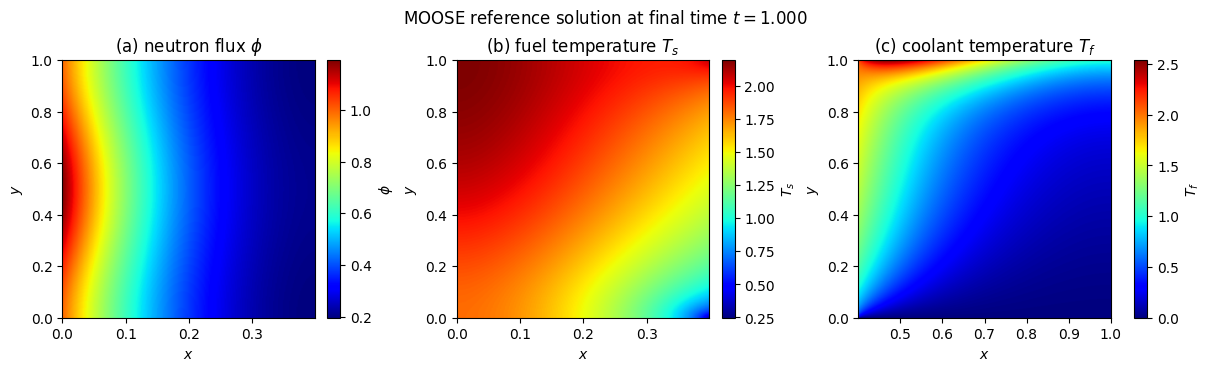

Saved:
  moose_reference_final_time_fields.png
  moose_reference_final_time_fields.pdf


In [14]:
import numpy as np
import matplotlib.pyplot as plt

npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

data = np.load(npz_path, allow_pickle=True)

x = np.asarray(data["x"], dtype=np.float64)
y = np.asarray(data["y"], dtype=np.float64)
t = np.asarray(data["t"] if "t" in data else data["time"], dtype=np.float64)

T = np.asarray(data["T"], dtype=np.float64)
phi = np.asarray(data["phi"], dtype=np.float64)

Ls = 0.4
k = -1

ix_right = np.argmin(np.abs(x - 1.0))

# Detect orientation using right-wall T=0 condition
right_if_axis0_is_x = np.max(np.abs(T[k, ix_right, :]))
right_if_axis1_is_x = np.max(np.abs(T[k, :, ix_right]))

if right_if_axis0_is_x < right_if_axis1_is_x:
    print("Detected orientation: array is [t, x, y]")
    def to_xy(A):
        return A
else:
    print("Detected orientation: array is [t, y, x], transposing")
    def to_xy(A):
        return A.T

Txy = to_xy(T[k])
phixy = to_xy(phi[k])

fuel_mask = x <= Ls + 1e-12
cool_mask = x >= Ls - 1e-12

x_fuel = x[fuel_mask]
x_cool = x[cool_mask]

phi_fuel = phixy[fuel_mask, :]
Ts_fuel = Txy[fuel_mask, :]
Tf_cool = Txy[cool_mask, :]

fields = [
    (phi_fuel, x_fuel, r"(a) neutron flux $\phi$", r"$\phi$"),
    (Ts_fuel,  x_fuel, r"(b) fuel temperature $T_s$", r"$T_s$"),
    (Tf_cool,  x_cool, r"(c) coolant temperature $T_f$", r"$T_f$"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

for ax, (arr, x_sub, title, cbar_label) in zip(axes, fields):
    im = ax.imshow(
        arr.T,
        origin="lower",
        extent=[x_sub.min(), x_sub.max(), y.min(), y.max()],
        aspect="auto",
        cmap="jet",
    )

    ax.set_title(title)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

fig.suptitle(rf"MOOSE reference solution at final time $t={t[k]:.3f}$")

plt.savefig("moose_reference_final_time_fields.png", dpi=300, bbox_inches="tight")
plt.savefig("moose_reference_final_time_fields.pdf", bbox_inches="tight")
plt.show()

print("Saved:")
print("  moose_reference_final_time_fields.png")
print("  moose_reference_final_time_fields.pdf")

In [12]:
import numpy as np

npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

data = np.load(npz_path, allow_pickle=True)

print("keys:", data.files)

x = np.asarray(data["x"], dtype=np.float64)
y = np.asarray(data["y"], dtype=np.float64)
t = np.asarray(data["t"] if "t" in data else data["time"], dtype=np.float64)

T = np.asarray(data["T"], dtype=np.float64)
phi = np.asarray(data["phi"], dtype=np.float64)

Ls = 0.4
k = -1

fuel_mask = x <= Ls + 1e-12
cool_mask = x >= Ls - 1e-12

ix_right = np.argmin(np.abs(x - 1.0))
ix_interface = np.argmin(np.abs(x - Ls))
iy_bottom = np.argmin(np.abs(y - 0.0))
iy_top = np.argmin(np.abs(y - 1.0))

print("\nDATA SHAPES")
print("x:", x.shape)
print("y:", y.shape)
print("t:", t.shape)
print("T:", T.shape)
print("phi:", phi.shape)

print("\nFINAL TIME")
print("t_final =", t[k])

print("\nBOUNDARY CHECKS assuming T[t, x, y]")
print("right boundary x=1, should be near 0:")
print("  min/max =", T[k, ix_right, :].min(), T[k, ix_right, :].max())

print("coolant bottom y=0, should NOT be forced to 0 in your pasted .i file:")
print("  min/max =", T[k, cool_mask, iy_bottom].min(), T[k, cool_mask, iy_bottom].max())

print("coolant top y=1, should look similar to bottom:")
print("  min/max =", T[k, cool_mask, iy_top].min(), T[k, cool_mask, iy_top].max())

print("interface x=0.4:")
print("  min/max =", T[k, ix_interface, :].min(), T[k, ix_interface, :].max())

def rel_symmetry_y(A):
    return np.linalg.norm(A - A[:, ::-1]) / (np.linalg.norm(A) + 1e-30)

phi_sym = rel_symmetry_y(phi[k, fuel_mask, :])
Ts_sym = rel_symmetry_y(T[k, fuel_mask, :])
Tf_sym = rel_symmetry_y(T[k, cool_mask, :])

print("\nY-SYMMETRY CHECK")
print("phi fuel symmetry error:", phi_sym)
print("Ts fuel symmetry error: ", Ts_sym)
print("Tf cool symmetry error: ", Tf_sym)

print("\nINTERPRETATION")
if abs(T[k, ix_right, :]).max() < 1e-8:
    print("Right-wall T=0 condition appears present.")
else:
    print("Right-wall T=0 condition does NOT appear present.")

if abs(T[k, cool_mask, iy_bottom]).max() < 1e-8:
    print("Coolant bottom appears to be Dirichlet T=0, which does NOT match your pasted .i file.")
else:
    print("Coolant bottom is not exactly zero, good for insulated-bottom case.")

if Tf_sym > 1e-2:
    print("Coolant field is not symmetric in y. This is suspicious for your no-advection pasted .i file.")
else:
    print("Coolant field is approximately symmetric in y.")

keys: ['t', 'x', 'y', 'phi', 'T', 'phi_fuel', 'Ts', 'Tf', 'T_interface']

DATA SHAPES
x: (513,)
y: (513,)
t: (1001,)
T: (1001, 513, 513)
phi: (1001, 513, 513)

FINAL TIME
t_final = 1.0

BOUNDARY CHECKS assuming T[t, x, y]
right boundary x=1, should be near 0:
  min/max = 0.0 0.9967151762474118
coolant bottom y=0, should NOT be forced to 0 in your pasted .i file:
  min/max = 0.0 0.0
coolant top y=1, should look similar to bottom:
  min/max = 0.9967151762474118 2.538100315780506
interface x=0.4:
  min/max = 0.0 2.091857124870463

Y-SYMMETRY CHECK
phi fuel symmetry error: 3.346102285437311e-16
Ts fuel symmetry error:  0.23195017849733532
Tf cool symmetry error:  0.9350254212783646

INTERPRETATION
Right-wall T=0 condition does NOT appear present.
Coolant bottom appears to be Dirichlet T=0, which does NOT match your pasted .i file.
Coolant field is not symmetric in y. This is suspicious for your no-advection pasted .i file.


Dataset keys: ['t', 'x', 'y', 'phi', 'T', 'phi_fuel', 'Ts', 'Tf', 'T_interface']

Reference shapes:
  x: (513,)
  y: (513,)
  t: (1001,)
  phi_ref: (1001, 513, 513)
  T_ref: (1001, 513, 513)

Assuming dataset orientation is [t, x, y].

Final time:
  index: 1000
  t_final: 1.0

Loaded Adam checkpoint:
  step: 10000
  width: 64
  layers: 4
  activation: tanh
  phi_scale: 1.5
  T_scale: 3.0
Using StoSQP theta: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_sqp_coupled_fixedbatch_jitter1.npy

StoSQP:
  theta path: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_sqp_coupled_fixedbatch_jitter1.npy
  theta size: 2073
  inferred hidden_dim: 30
  inferred num_hidden: 3
  layer_sizes: [3, 30, 30, 30, 3]
Using ALM theta: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_fixed_no_noise_best.npy

ALM:
  theta path: /projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_fixed_no_noise_best.npy
  theta size: 2073
  inferred hidden_dim: 30
  inferred

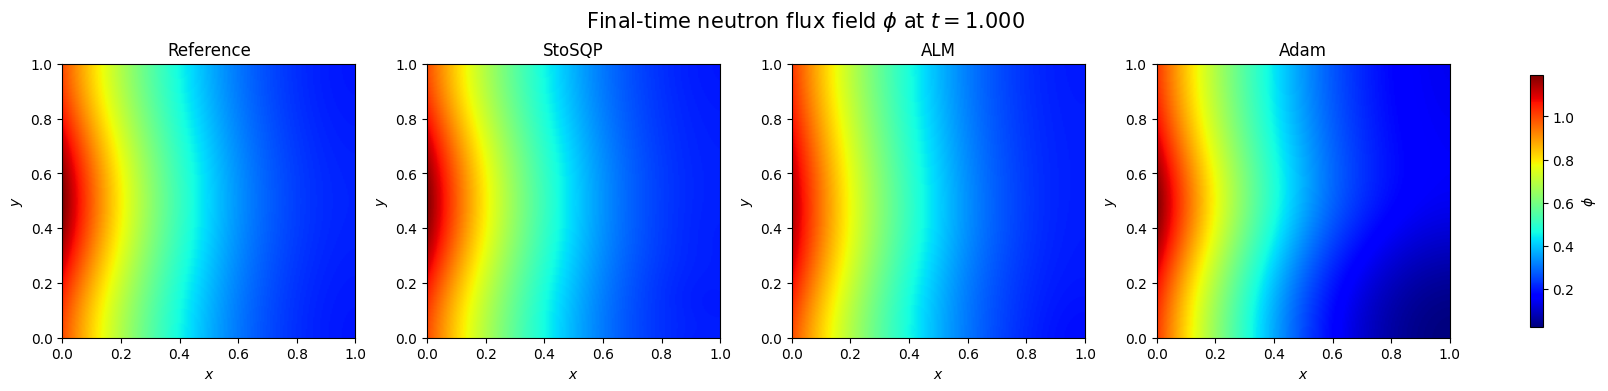


Saved:
  figure_phi_reference_stosqp_alm_adam_jet.png
  figure_phi_reference_stosqp_alm_adam_jet.pdf


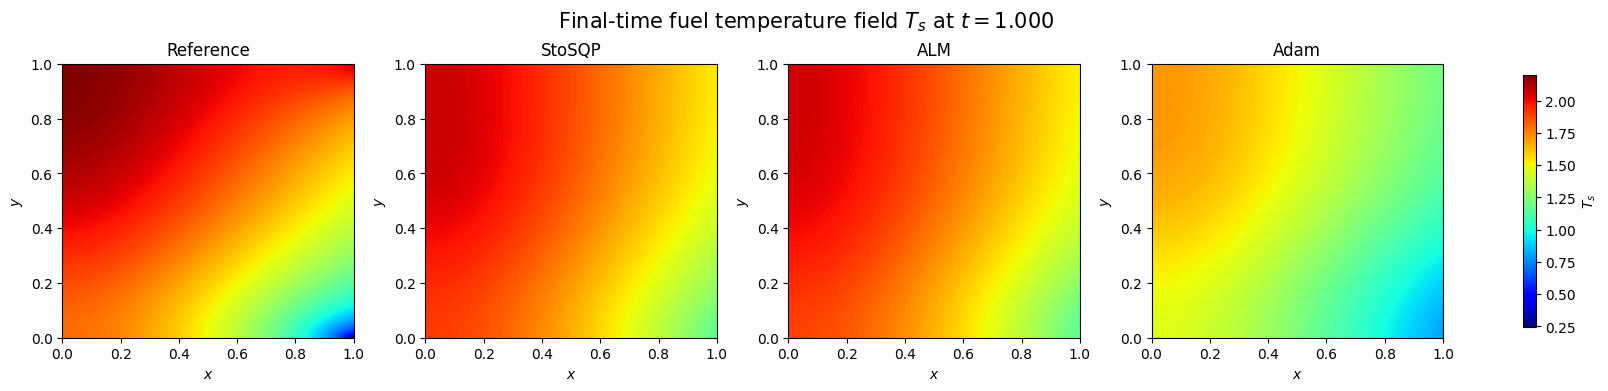


Saved:
  figure_Ts_reference_stosqp_alm_adam_jet.png
  figure_Ts_reference_stosqp_alm_adam_jet.pdf


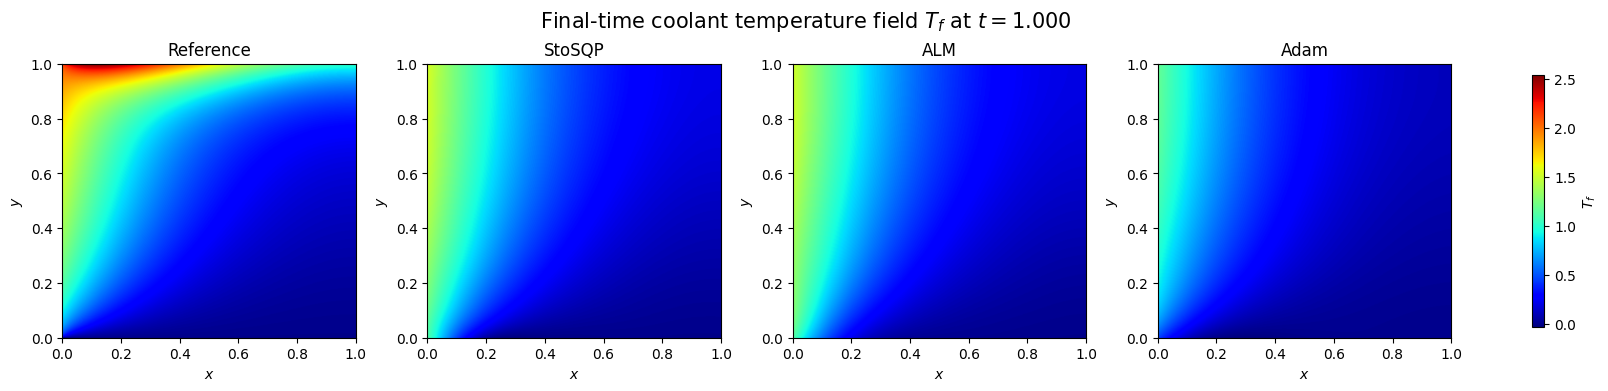


Saved:
  figure_Tf_reference_stosqp_alm_adam_jet.png
  figure_Tf_reference_stosqp_alm_adam_jet.pdf

Done.


In [ ]:
# ============================================================
# Final-time comparison plots for the coupled neutron-thermal benchmark
#
# Figures:
#   1) phi  : Reference | StoSQP | ALM | Adam
#   2) Ts   : Reference | StoSQP | ALM | Adam
#   3) Tf   : Reference | StoSQP | ALM | Adam
#
# Colormap:
#   jet  (to mimic the M2PDE figure style)
#
# Notes:
# - This script assumes the reference dataset is the ADVECTION case.
# - StoSQP and ALM are assumed to be single-MLP flat theta vectors
#   with outputs [phi, Ts, Tf].
# - Adam is assumed to come from checkpoint_latest.pkl and uses
#   separate networks for phi / ts / tf.
#
# ============================================================

import os
os.environ["JAX_ENABLE_X64"] = "1"

import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp


# ============================================================
# USER SETTINGS
# ============================================================

# ----------------------------
# paths
# ----------------------------
npz_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/moose/sqp_dataset.npz"

# Adam checkpoint
adam_ckpt_path = "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/adam_jax_moose_output/checkpoint_latest.pkl"

# StoSQP theta candidates
stosqp_theta_candidates = [
    "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_sqp_coupled_fixedbatch_jitter1.npy",

]

# ALM theta candidates
alm_theta_candidates = [
    "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_fixed_no_noise_best.npy",
    "/projects/549120ce-e7e0-45e0-a453-c9903649fea2/sqp/theta_alm_coupled_fixed_no_noise_final.npy",
    "theta_alm_coupled_fixed_no_noise_best.npy",
    "theta_alm_coupled_fixed_no_noise_final.npy",
]

# ----------------------------
# plotting options
# ----------------------------
CMAP_NAME = "jet"              # paper-style
USE_NORMALIZED_LOCAL_X = True  # makes panels look more like M2PDE
SAVE_DPI = 300

# ----------------------------
# geometry
# ----------------------------
Ls = 0.4
Lf = 0.6
Ly = 1.0
T_end = 1.0

# dtype
USE_X64 = True
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = DTYPE(1e-12)


# ============================================================
# HELPERS
# ============================================================

def find_first_existing(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"Using {name}: {p}")
            return p
    raise FileNotFoundError(
        f"Could not find {name}. Checked:\n" + "\n".join(candidates)
    )


def finite_minmax(*arrays):
    vals = []
    for arr in arrays:
        aa = np.asarray(arr, dtype=np.float64)
        aa = aa[np.isfinite(aa)]
        if aa.size > 0:
            vals.append(aa)
    vals = np.concatenate(vals)
    return vals.min(), vals.max()


def param_count(hidden_dim, num_hidden):
    layer_sizes = [3] + [hidden_dim] * num_hidden + [3]
    total = 0
    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += m * n + n
    return total


def infer_arch(theta_size):
    matches = []
    for H in range(5, 101):
        for L in range(1, 8):
            if param_count(H, L) == theta_size:
                matches.append((H, L))
    return matches


def choose_arch(theta_size):
    matches = infer_arch(theta_size)
    if len(matches) == 0:
        raise ValueError(f"Could not infer architecture from theta size {theta_size}.")
    if (35, 3) in matches:
        return 35, 3
    if (30, 3) in matches:
        return 30, 3
    return matches[0]


def unflatten_params(theta, layer_sizes):
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape((m, n))
        idx += w_size

        b = theta[idx:idx + b_size].reshape((n,))
        idx += b_size

        params.append({"W": W, "b": b})

    if idx != theta.size:
        raise ValueError(f"Did not consume all theta entries: used {idx}, total {theta.size}")

    return params


# ============================================================
# LOAD REFERENCE DATA
# ============================================================

data = np.load(npz_path, allow_pickle=True)
print("Dataset keys:", data.files)

x = np.asarray(data["x"], dtype=np.float64)
y = np.asarray(data["y"], dtype=np.float64)
time_arr = np.asarray(data["t"] if "t" in data else data["time"], dtype=np.float64)

phi_ref = np.asarray(data["phi"], dtype=np.float64)
T_ref   = np.asarray(data["T"], dtype=np.float64)

nt, nx, ny = T_ref.shape

print("\nReference shapes:")
print("  x:", x.shape)
print("  y:", y.shape)
print("  t:", time_arr.shape)
print("  phi_ref:", phi_ref.shape)
print("  T_ref:", T_ref.shape)

# Expecting the detected orientation to be [t, x, y]
# based on your earlier diagnostics.
print("\nAssuming dataset orientation is [t, x, y].")

# masks
tol = 1e-12
fuel_mask = x <= Ls + tol
cool_mask = x >= Ls - tol

x_fuel = x[fuel_mask]
x_cool = x[cool_mask]

# local normalized x for separate panels
xi_fuel = (x_fuel - x_fuel.min()) / (x_fuel.max() - x_fuel.min())
xi_cool = (x_cool - x_cool.min()) / (x_cool.max() - x_cool.min())

x_plot_fuel = xi_fuel if USE_NORMALIZED_LOCAL_X else x_fuel
x_plot_cool = xi_cool if USE_NORMALIZED_LOCAL_X else x_cool

# final time
k_final = nt - 1
t_final = float(time_arr[k_final])
print("\nFinal time:")
print("  index:", k_final)
print("  t_final:", t_final)

XX, YY = np.meshgrid(x, y, indexing="ij")
TT = np.full_like(XX, t_final, dtype=np.float64)
X_eval = np.stack(
    [XX.reshape(-1), YY.reshape(-1), TT.reshape(-1)],
    axis=1
)

chunk = 65536

x_min = DTYPE(0.0)
x_max = DTYPE(Ls + Lf)
y_min = DTYPE(0.0)
y_max = DTYPE(Ly)
t_min = DTYPE(0.0)
t_max = DTYPE(T_end)


# ============================================================
# ADAM MODEL
# ============================================================

with open(adam_ckpt_path, "rb") as f:
    adam_ckpt = pickle.load(f)

adam_params = adam_ckpt["params"]
adam_cfg = adam_ckpt["config"]

print("\nLoaded Adam checkpoint:")
print("  step:", adam_ckpt["step"])
print("  width:", adam_cfg["width"])
print("  layers:", adam_cfg["layers"])
print("  activation:", adam_cfg["activation"])
print("  phi_scale:", adam_cfg["phi_scale"])
print("  T_scale:", adam_cfg["T_scale"])


def activate(z, activation):
    if activation == "tanh":
        return jnp.tanh(z)
    elif activation == "silu":
        return z * jax.nn.sigmoid(z)
    else:
        raise ValueError("activation must be tanh or silu")


def normalize_xyt_adam(xyt):
    # Adam training used [0,1]^3 -> [-1,1]^3
    return 2.0 * xyt - 1.0


def mlp_apply_adam(mlp_params, x_in, activation):
    h = x_in
    for W, b in mlp_params[:-1]:
        h = activate(jnp.dot(h, W) + b, activation)
    W, b = mlp_params[-1]
    return jnp.dot(h, W) + b


def forward_all_adam(params, xyt, cfg):
    z = normalize_xyt_adam(xyt)

    phi = cfg["phi_scale"] * mlp_apply_adam(params["phi"], z, cfg["activation"])
    Ts  = cfg["T_scale"]   * mlp_apply_adam(params["ts"],  z, cfg["activation"])
    Tf  = cfg["T_scale"]   * mlp_apply_adam(params["tf"],  z, cfg["activation"])

    return jnp.concatenate([phi, Ts, Tf], axis=-1)


@jax.jit
def forward_batch_adam(xyt):
    return forward_all_adam(adam_params, xyt, adam_cfg)


adam_pred_list = []
for s in range(0, X_eval.shape[0], chunk):
    X_chunk = jnp.asarray(X_eval[s:s + chunk], dtype=DTYPE)
    pred_chunk = np.asarray(forward_batch_adam(X_chunk))
    adam_pred_list.append(pred_chunk)

adam_pred = np.concatenate(adam_pred_list, axis=0)

phi_adam = adam_pred[:, 0].reshape(nx, ny)
Ts_adam  = adam_pred[:, 1].reshape(nx, ny)
Tf_adam  = adam_pred[:, 2].reshape(nx, ny)


# ============================================================
# COMMON FLAT-THETA MODEL (for StoSQP and ALM)
# ============================================================

def normalize_xyt_flat(X):
    xx = X[:, 0:1]
    yy = X[:, 1:2]
    tt = X[:, 2:3]

    x_n = DTYPE(2.0) * (xx - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    y_n = DTYPE(2.0) * (yy - y_min) / (y_max - y_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (tt - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)

    return jnp.concatenate([x_n, y_n, t_n], axis=1)


def mlp_apply_flat(params, X):
    h = normalize_xyt_flat(X)

    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]
        if i < len(params) - 1:
            h = jnp.tanh(h)

    # outputs = [phi, Ts, Tf]
    return h


def evaluate_flat_theta(theta_path, model_name):
    theta_np = np.load(theta_path)
    theta = jnp.asarray(theta_np, dtype=DTYPE)

    hidden_dim, num_hidden = choose_arch(theta_np.size)
    layer_sizes = [3] + [hidden_dim] * num_hidden + [3]

    print(f"\n{model_name}:")
    print("  theta path:", theta_path)
    print("  theta size:", theta_np.size)
    print("  inferred hidden_dim:", hidden_dim)
    print("  inferred num_hidden:", num_hidden)
    print("  layer_sizes:", layer_sizes)

    params = unflatten_params(theta, layer_sizes)

    @jax.jit
    def forward_batch(X):
        return mlp_apply_flat(params, X)

    pred_list = []
    for s in range(0, X_eval.shape[0], chunk):
        X_chunk = jnp.asarray(X_eval[s:s + chunk], dtype=DTYPE)
        pred_chunk = np.asarray(forward_batch(X_chunk))
        pred_list.append(pred_chunk)

    pred = np.concatenate(pred_list, axis=0)

    phi = pred[:, 0].reshape(nx, ny)
    Ts  = pred[:, 1].reshape(nx, ny)
    Tf  = pred[:, 2].reshape(nx, ny)

    return phi, Ts, Tf


# StoSQP
stosqp_theta_path = find_first_existing(stosqp_theta_candidates, "StoSQP theta")
phi_sqp, Ts_sqp, Tf_sqp = evaluate_flat_theta(stosqp_theta_path, "StoSQP")

# ALM
alm_theta_path = find_first_existing(alm_theta_candidates, "ALM theta")
phi_alm, Ts_alm, Tf_alm = evaluate_flat_theta(alm_theta_path, "ALM")


# ============================================================
# FINAL-TIME REFERENCE FIELDS
# ============================================================

phi_true = phi_ref[k_final]
T_true   = T_ref[k_final]

# restrict to subdomains
phi_ref_plot  = phi_true[fuel_mask, :]
phi_sqp_plot  = phi_sqp[fuel_mask, :]
phi_alm_plot  = phi_alm[fuel_mask, :]
phi_adam_plot = phi_adam[fuel_mask, :]

Ts_ref_plot   = T_true[fuel_mask, :]
Ts_sqp_plot   = Ts_sqp[fuel_mask, :]
Ts_alm_plot   = Ts_alm[fuel_mask, :]
Ts_adam_plot  = Ts_adam[fuel_mask, :]

Tf_ref_plot   = T_true[cool_mask, :]
Tf_sqp_plot   = Tf_sqp[cool_mask, :]
Tf_alm_plot   = Tf_alm[cool_mask, :]
Tf_adam_plot  = Tf_adam[cool_mask, :]


# ============================================================
# PLOTTING
# ============================================================

def make_one_field_figure(
    arrays,
    x_sub,
    y,
    field_title,
    field_symbol,
    out_png,
    out_pdf,
    cmap="jet",
):
    """
    arrays = [ref, sqp, alm, adam]
    each array shape = (nx_sub, ny)
    """

    titles = ["Reference", "StoSQP", "ALM", "Adam"]
    vmin, vmax = finite_minmax(*arrays)

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), constrained_layout=True)

    for ax, arr, title in zip(axes, arrays, titles):
        im = ax.imshow(
            arr.T,
            origin="lower",
            extent=[x_sub.min(), x_sub.max(), y.min(), y.max()],
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")

    cbar = fig.colorbar(im, ax=axes, shrink=0.92)
    cbar.set_label(field_symbol)

    fig.suptitle(field_title, fontsize=15)

    plt.savefig(out_png, dpi=SAVE_DPI, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    print("\nSaved:")
    print(" ", out_png)
    print(" ", out_pdf)


# ----------------------------
# Figure 1: phi
# ----------------------------
make_one_field_figure(
    arrays=[
        phi_ref_plot,
        phi_sqp_plot,
        phi_alm_plot,
        phi_adam_plot,
    ],
    x_sub=x_plot_fuel,
    y=y,
    field_title=rf"Final-time neutron flux field $\phi$ at $t={t_final:.3f}$",
    field_symbol=r"$\phi$",
    out_png="figure_phi_reference_stosqp_alm_adam_jet.png",
    out_pdf="figure_phi_reference_stosqp_alm_adam_jet.pdf",
    cmap=CMAP_NAME,
)

# ----------------------------
# Figure 2: Ts
# ----------------------------
make_one_field_figure(
    arrays=[
        Ts_ref_plot,
        Ts_sqp_plot,
        Ts_alm_plot,
        Ts_adam_plot,
    ],
    x_sub=x_plot_fuel,
    y=y,
    field_title=rf"Final-time fuel temperature field $T_s$ at $t={t_final:.3f}$",
    field_symbol=r"$T_s$",
    out_png="figure_Ts_reference_stosqp_alm_adam_jet.png",
    out_pdf="figure_Ts_reference_stosqp_alm_adam_jet.pdf",
    cmap=CMAP_NAME,
)

# ----------------------------
# Figure 3: Tf
# ----------------------------
make_one_field_figure(
    arrays=[
        Tf_ref_plot,
        Tf_sqp_plot,
        Tf_alm_plot,
        Tf_adam_plot,
    ],
    x_sub=x_plot_cool,
    y=y,
    field_title=rf"Final-time coolant temperature field $T_f$ at $t={t_final:.3f}$",
    field_symbol=r"$T_f$",
    out_png="figure_Tf_reference_stosqp_alm_adam_jet.png",
    out_pdf="figure_Tf_reference_stosqp_alm_adam_jet.pdf",
    cmap=CMAP_NAME,
)

print("\nDone.")